In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [63]:
df = pd.read_csv('data.csv')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [65]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df.head()
df=df.set_index('id')

In [68]:
df.columns.tolist()

['diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'Unnamed: 32']

In [69]:
df = df.drop(['Unnamed: 32'], axis=1)

In [70]:
unique = df['diagnosis'].unique()
print(unique)

['M' 'B']


In [71]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [72]:
#now for svm
x= df[['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst'
 ]]
y = df['diagnosis']

In [73]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state=42)

In [74]:
svm_model = SVC(kernel= 'linear', C=1.0)

In [75]:
svm_model.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [76]:
svm_pred= svm_model.predict(x_test)

In [77]:
print(f"SVM accuracy score: {accuracy_score(y_test, svm_pred)}",
      f"SVM classification_report: {classification_report(y_test, svm_pred)}")

SVM accuracy score: 0.956140350877193 SVM classification_report:               precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [78]:
#now for decision tree
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [79]:
dt_pred= dt_model.predict(x_test)

In [80]:
print(f"Decision tree accuracy score: {accuracy_score(y_test, dt_pred)}",
      f"Decision tree classification_report: {classification_report(y_test, dt_pred)}")

Decision tree accuracy score: 0.9385964912280702 Decision tree classification_report:               precision    recall  f1-score   support

           0       0.94      0.96      0.95        71
           1       0.93      0.91      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [81]:
# making a grid to choose the best depth
param_grid = {'max_depth': list(range(1,11))}
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid= param_grid,
    cv = 5,
    scoring= 'accuracy'
)
grid_search.fit(x_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [82]:
print(f"Best max depth: {grid_search.best_params_['max_depth']}\n",
      f"Best accuracy: {grid_search.best_score_:.2f}")

Best max depth: 4
 Best accuracy: 0.93


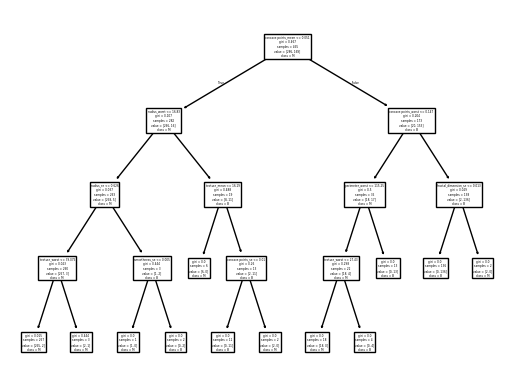

In [92]:
plt.Figure(figsize=(25,20))
plot_tree(
    dt_model,
    feature_names= x.columns.tolist(),
    class_names = ['M', 'B']
)
plt.show()

In [ ]:
# go back and change the depth to 4 afte the grid said it's better
# we can try KNN now

In [97]:
scaler = StandardScaler()
knn = KNeighborsClassifier(n_neighbors=3)
x_train_k = scaler.fit_transform(x_train)
x_test_k = scaler.transform(x_test)

In [99]:
knn.fit(x_train_k, y_train)
knn_pred = knn.predict(x_test_k)

In [100]:
print(f"KNN accuracy score: {accuracy_score(y_test, knn_pred)}",
      f"KNN classification_report: {classification_report(y_test, knn_pred)}")

KNN accuracy score: 0.9473684210526315 KNN classification_report:               precision    recall  f1-score   support

           0       0.95      0.97      0.96        71
           1       0.95      0.91      0.93        43

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

